# Linear Algebra Done Right — 챕터별 완전 가이드
**Sheldon Axler, 4th Edition (2024)**

> *"Linear algebra is the study of linear maps on finite-dimensional vector spaces."*

---

## 목차

| Chapter | 제목 | 응용 |
|---------|------|------|
| Ch.1 | Vector Spaces | 기초통계 — 데이터 중심화 |
| Ch.2 | Finite-Dimensional Vector Spaces | 기초통계 — 공분산 유효 차원 |
| Ch.3 | Linear Maps | 머신러닝 — 선형회귀 (Normal Equation) |
| Ch.4 | Polynomials | 기초통계 — 다항 회귀 |
| Ch.5 | Eigenvalues & Eigenvectors | 머신러닝 — PCA |
| Ch.6 | Inner Product Spaces | 머신러닝 — 코사인 유사도 |
| Ch.7 | Operators on Inner Product Spaces (SVD) | 머신러닝 — 차원 축소 |
| Ch.8 | Operators on Complex Vector Spaces | 딥러닝 — RNN 안정성 |
| Ch.9 | Multilinear Algebra & Determinants | 머신러닝 — 마할라노비스 거리 |
| Ch.10 | Trace & Determinant (Deep Learning) | 딥러닝 — MLP 역전파 |

---

### 코드 규칙
- **NumPy 직접 구현** → 원리 이해
- **라이브러리 활용** → 실전 사용
- **`assert np.allclose(...)`** → 두 결과가 동일함을 검증
- **`fig, ax`** → 모든 시각화는 matplotlib axes 객체 사용


## 환경 설정 (공통)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import linalg as spla
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import mahalanobis
from scipy.linalg import expm as scipy_expm
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ── 공통 스타일 ────────────────────────────────────────────────
plt.rcParams.update({
    "font.family"     : "DejaVu Sans",
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor"  : "#1a1a2e",
    "axes.edgecolor"  : "#444466",
    "axes.labelcolor" : "#ccccff",
    "xtick.color"     : "#aaaacc",
    "ytick.color"     : "#aaaacc",
    "text.color"      : "#e0e0ff",
    "grid.color"      : "#2a2a4a",
    "grid.alpha"      : 0.6,
    "lines.linewidth" : 2,
    "axes.titlesize"  : 12,
    "axes.labelsize"  : 10,
})
C = ["#7eb8f7", "#f78fb3", "#a8ff78", "#ffd700", "#ff6b6b", "#b8f7e8"]

print("모든 라이브러리 로드 완료")


모든 라이브러리 로드 완료


---
# Chapter 1 — Vector Spaces (벡터 공간)

## 핵심 원리

### 1. 벡터 공간의 정의
집합 $V$가 **덧셈**과 **스칼라 곱**을 갖추고 다음 8가지 공리를 만족하면 $V$를 **벡터 공간(vector space)** 이라 한다.


- **교환 법칙:** $u + v = v + u$
- **결합 법칙:** $(u+v)+w = u+(v+w)$
- **덧셈 항등원:** $\exists\, 0 \in V : v+0 = v$
- **덧셈 역원:** $\forall v \,\exists\, {-v} : v + ({-v}) = 0$
- **스칼라 항등원:** $1 \cdot v = v$
- **스칼라 분배:** $a(u+v) = au + av$
- **벡터 분배:** $(a+b)v = av + bv$
- **결합:** $(ab)v = a(bv)$

### 2. $\mathbb{R}^n$과 $\mathbb{C}^n$
$$\mathbb{R}^n = \{(x_1, \ldots, x_n) \mid x_i \in \mathbb{R}\}$$

덧셈: $(x_1,\ldots,x_n)+(y_1,\ldots,y_n) = (x_1+y_1,\ldots,x_n+y_n)$

스칼라 곱: $\lambda(x_1,\ldots,x_n) = (\lambda x_1,\ldots,\lambda x_n)$

### 3. 부분공간(Subspace)
$U \subseteq V$가 부분공간이 되려면:
- $0 \in U$ (덧셈 항등원 포함)
- $u, w \in U \Rightarrow u+w \in U$ (덧셈에 닫힘)
- $\lambda \in \mathbb{F},\, u \in U \Rightarrow \lambda u \in U$ (스칼라 곱에 닫힘)

### 4. 직합(Direct Sum)
$V = U_1 \oplus U_2$ iff 모든 $v \in V$를 $v = u_1 + u_2\,(u_i \in U_i)$로 **유일하게** 나타낼 수 있다.

---
## 기초통계 응용: 데이터 중심화 (Data Centering)

데이터 행렬 $X \in \mathbb{R}^{n \times p}$에서 **평균 벡터** $\bar{x}$를 빼는 연산은
원점이 $\bar{x}$인 부분공간으로의 이동과 같다.

$$X_{\text{centered}} = X - \mathbf{1}\bar{x}^\top, \quad \bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$$


In [46]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.1 — 벡터 공간 8대 공리 직접 검증
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
v1 = np.array([1.0, 2.0, 3.0])
v2 = np.array([4.0, 5.0, 6.0])
v3 = np.array([7.0, 8.0, 9.0])
a, b = 2.5, -1.3

print("=== 벡터 공간 8대 공리 검증 ===")
print(f"1. 교환 법칙    v1+v2 == v2+v1 : {np.allclose(v1+v2, v2+v1)}")
print(f"2. 결합 법칙    (v1+v2)+v3 == v1+(v2+v3) : {np.allclose((v1+v2)+v3, v1+(v2+v3))}")
print(f"3. 덧셈 항등원  v1+0 == v1 : {np.allclose(v1+np.zeros(3), v1)}")
print(f"4. 덧셈 역원    v1+(-v1) == 0 : {np.allclose(v1+(-v1), np.zeros(3))}")
print(f"5. 스칼라 항등원 1*v1 == v1 : {np.allclose(1*v1, v1)}")
print(f"6. 스칼라 분배  a*(v1+v2) == a*v1+a*v2 : {np.allclose(a*(v1+v2), a*v1+a*v2)}")
print(f"7. 벡터 분배    (a+b)*v1 == a*v1+b*v1 : {np.allclose((a+b)*v1, a*v1+b*v1)}")
print(f"8. 결합         (a*b)*v1 == a*(b*v1) : {np.allclose((a*b)*v1, a*(b*v1))}")


=== 벡터 공간 8대 공리 검증 ===
1. 교환 법칙    v1+v2 == v2+v1 : True
2. 결합 법칙    (v1+v2)+v3 == v1+(v2+v3) : True
3. 덧셈 항등원  v1+0 == v1 : True
4. 덧셈 역원    v1+(-v1) == 0 : True
5. 스칼라 항등원 1*v1 == v1 : True
6. 스칼라 분배  a*(v1+v2) == a*v1+a*v2 : True
7. 벡터 분배    (a+b)*v1 == a*v1+b*v1 : True
8. 결합         (a*b)*v1 == a*(b*v1) : True


In [47]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.1 — 부분공간 검사 & 데이터 중심화 (NumPy vs sklearn)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── ① NumPy 직접 구현 ────────────────────────────────────
X = np.array([[2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0],
              [1.0, 0.0, 2.0]])

mean_np     = X.mean(axis=0)           # 평균 벡터 μ
centered_np = X - mean_np              # X - μ

# 부분공간 검사 (span{v1, v2}에 w가 있는가?)
v1b = np.array([1.0, 2.0, 3.0])
v2b = np.array([4.0, 5.0, 6.0])
w   = np.array([7.0, 9.0, 11.0])
A_sub = np.column_stack([v1b, v2b])
coeffs, _, _, _ = np.linalg.lstsq(A_sub, w, rcond=None)
in_span = np.allclose(A_sub @ coeffs, w)

print(f"[NumPy] 평균 벡터 μ = {mean_np}")
print(f"[NumPy] w ∈ span(v1,v2)? → {in_span}  (계수: {coeffs.round(4)})")

# ── ② sklearn 라이브러리 활용 ────────────────────────────
scaler       = StandardScaler(with_std=False)   # 평균만 제거
centered_lib = scaler.fit_transform(X)
mean_lib     = scaler.mean_

print(f"\n[sklearn] 평균 벡터 μ = {mean_lib}")

# ── ③ 결과 검증 ─────────────────────────────────────────
assert np.allclose(mean_np, mean_lib),           "평균 벡터 불일치!"
assert np.allclose(centered_np, centered_lib),   "중심화 결과 불일치!"
print("\nNumPy 직접 구현 == sklearn StandardScaler (결괏값 동일)")


[NumPy] 평균 벡터 μ = [2.66666667 3.         4.33333333]
[NumPy] w ∈ span(v1,v2)? → True  (계수: [0.3333 1.6667])

[sklearn] 평균 벡터 μ = [2.66666667 3.         4.33333333]

NumPy 직접 구현 == sklearn StandardScaler (결괏값 동일)


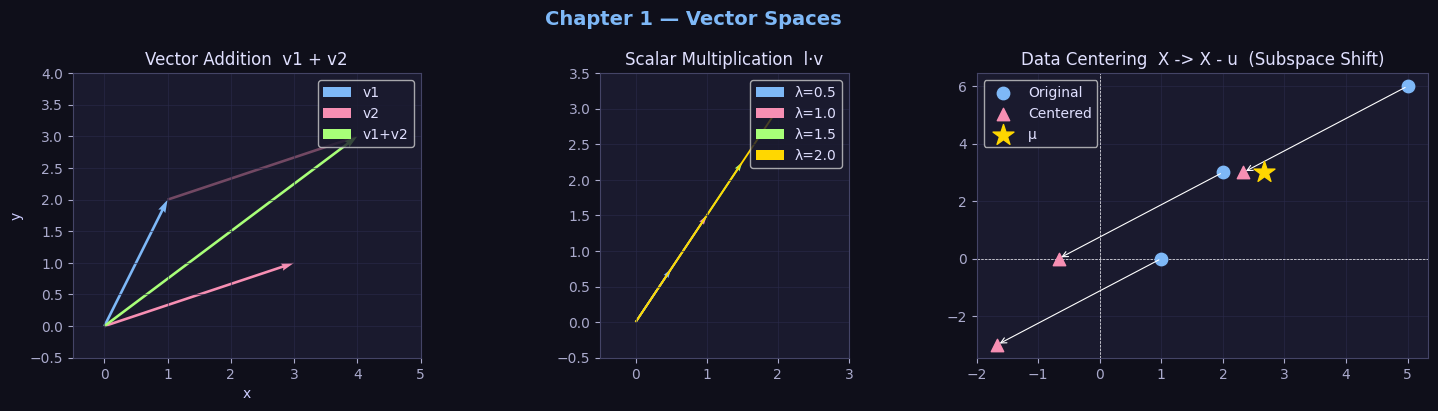

In [48]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.1 — 시각화: 벡터 덧셈 / 스칼라 곱 / 데이터 중심화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 1 — Vector Spaces", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 벡터 덧셈 ────────────────────────────────
ax = axes[0]
ax.set_title("Vector Addition  v1 + v2")
a2, b2 = np.array([1, 2]), np.array([3, 1])
kw = dict(angles='xy', scale_units='xy', scale=1)
ax.quiver(0,0,a2[0],a2[1], **kw, color=C[0], label='v1')
ax.quiver(0,0,b2[0],b2[1], **kw, color=C[1], label='v2')
ax.quiver(a2[0],a2[1],b2[0],b2[1], **kw, color=C[1], alpha=0.4)  # 평행이동
ax.quiver(0,0,*(a2+b2),             **kw, color=C[2], label='v1+v2')
ax.set_xlim(-0.5,5); ax.set_ylim(-0.5,4)
ax.set_aspect('equal'); ax.legend(); ax.grid(True)
ax.set_xlabel("x"); ax.set_ylabel("y")

# ── 서브플롯 2: 스칼라 곱 ────────────────────────────────
ax = axes[1]
ax.set_title("Scalar Multiplication  l·v")
v = np.array([1, 1.5])
for i, s in enumerate([0.5, 1.0, 1.5, 2.0]):
    ax.quiver(0,0,*(s*v), **kw, color=C[i % len(C)], label=f'λ={s}')
ax.set_xlim(-0.5,3); ax.set_ylim(-0.5,3.5)
ax.set_aspect('equal'); ax.legend(); ax.grid(True)

# ── 서브플롯 3: 데이터 중심화 ─────────────────────────────
ax = axes[2]
ax.set_title("Data Centering  X -> X - u  (Subspace Shift)")
ax.scatter(X[:,0], X[:,1], color=C[0], s=80, zorder=3, label='Original')
ax.scatter(centered_np[:,0], centered_np[:,1], color=C[1], marker='^',
           s=80, zorder=3, label='Centered')
ax.scatter(*mean_np[:2], color=C[3], marker='*', s=250, zorder=5, label='μ')
for i in range(len(X)):
    ax.annotate('', xy=centered_np[i,:2], xytext=X[i,:2],
                arrowprops=dict(arrowstyle='->', color='white', lw=0.8))
ax.axhline(0, color='white', lw=0.5, ls='--')
ax.axvline(0, color='white', lw=0.5, ls='--')
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("ch1_vector_spaces.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 2 — Finite-Dimensional Vector Spaces (유한차원 벡터 공간)

## 핵심 원리

### 1. 선형 결합 (Linear Combination) & Span
$$\text{span}(v_1,\ldots,v_m) = \{a_1 v_1 + \cdots + a_m v_m \mid a_i \in \mathbb{F}\}$$

### 2. 선형 독립 (Linear Independence)
- $v_1,\ldots,v_m$이 **선형 독립** ⟺ $a_1v_1+\cdots+a_mv_m=0 \Rightarrow a_1=\cdots=a_m=0$

- 반대로 한 벡터가 나머지의 선형 결합으로 표현되면 **선형 종속**이다.

### 3. 기저 (Basis)
- $B = (v_1,\ldots,v_n)$이 $V$의 **기저** ⟺ $V$의 모든 원소를 **유일하게** 선형 결합으로 표현.

- 즉 기저는 "선형 독립"이면서 "span이 $V$ 전체"인 리스트.

### 4. 차원 (Dimension)
$$\dim V = \text{기저의 원소 수}$$

> **정리**: 유한차원 벡터 공간의 모든 기저는 같은 개수를 갖는다.

### 5. 행렬의 rank와 차원
$$\text{rank}(A) = \dim(\text{col-space of } A) = \dim(\text{row-space of } A)$$

---
## 기초통계 응용: 공분산 행렬의 유효 차원

- 데이터 $X \in \mathbb{R}^{n \times p}$의 공분산 행렬
$$\Sigma = \frac{1}{n-1}(X-\bar{X})^\top(X-\bar{X})$$
- 의 rank가 데이터의 유효 차원(intrinsic dimension)이다.

- 선형 종속 변수가 있으면 $\text{rank}(\Sigma) < p$.


In [49]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.2 — 선형 독립 / 기저 / 차원 (NumPy vs sklearn PCA)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── ① NumPy: rank로 선형 독립 검사 ──────────────────────
V_mat = np.array([[1,0,0],
                  [0,1,0],
                  [0,0,1],
                  [1,1,0]], dtype=float)      # 4개 벡터, R^3
rank_V = np.linalg.matrix_rank(V_mat)
print(f"[NumPy] 4개 벡터의 rank = {rank_V}  → 최대 {rank_V}개가 선형 독립")
print(f"        dim(R^3) = 3  ∴ 기저는 3개로 충분")

# QR 분해로 정규직교 기저 추출
Q, R = np.linalg.qr(V_mat.T)   # V.T : (3, 4)
print(f"\n[NumPy QR] 정규직교 기저 Q (각 열):\n{Q.round(4)}")
print(f"  검증 Q^T Q ≈ I: {np.allclose(Q.T @ Q, np.eye(3))}")

# ── ② 공분산 rank = 유효 차원 ────────────────────────────
np.random.seed(0)
X5 = np.random.randn(100, 5)
X5[:, 4] = X5[:, 0] + X5[:, 1]       # 5열 = 1열+2열 → 선형 종속
X5c = X5 - X5.mean(0)
cov5 = X5c.T @ X5c / (len(X5) - 1)
rank_cov = np.linalg.matrix_rank(cov5)
print(f"\n[NumPy] 5차원 데이터(1개 종속) 공분산 rank = {rank_cov}  (유효 차원)")

# ── ③ sklearn PCA: 누적 분산비로 유효 차원 ─────────────
pca = PCA()
pca.fit(X5)
cumvar = np.cumsum(pca.explained_variance_ratio_)
dim_pca = int(np.searchsorted(cumvar, 0.9999) + 1)
print(f"[sklearn PCA] 누적 분산 99.99% 달성 차원 수 = {dim_pca}")

assert rank_cov == dim_pca, "차원 불일치!"
print("\nNumPy rank == sklearn PCA 유효 차원 (결괏값 동일)")


[NumPy] 4개 벡터의 rank = 3  → 최대 3개가 선형 독립
        dim(R^3) = 3  ∴ 기저는 3개로 충분

[NumPy QR] 정규직교 기저 Q (각 열):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  검증 Q^T Q ≈ I: True

[NumPy] 5차원 데이터(1개 종속) 공분산 rank = 4  (유효 차원)
[sklearn PCA] 누적 분산 99.99% 달성 차원 수 = 4

NumPy rank == sklearn PCA 유효 차원 (결괏값 동일)


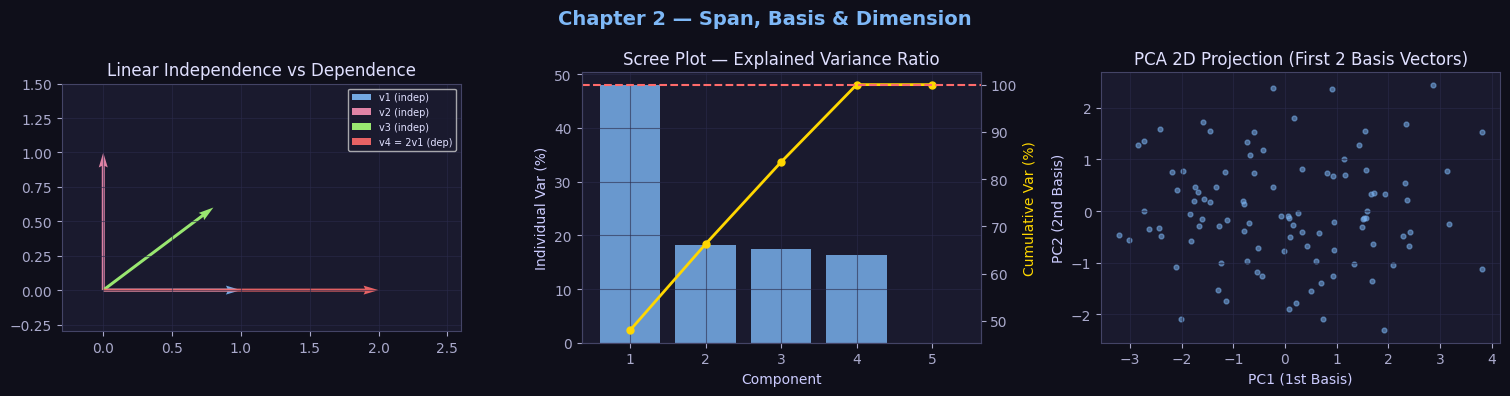

In [50]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.2 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 2 — Span, Basis & Dimension", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 선형 독립 vs 종속 ───────────────────────
ax = axes[0]
ax.set_title("Linear Independence vs Dependence")
kw = dict(angles='xy', scale_units='xy', scale=1)
pairs = [([1,0],"v1 (indep)",C[0]), ([0,1],"v2 (indep)",C[1]),
         ([0.8,0.6],"v3 (indep)",C[2]), ([2.0,0.0],"v4 = 2v1 (dep)",C[4])]
for v, lb, c in pairs:
    ax.quiver(0,0,v[0],v[1], **kw, color=c, label=lb, alpha=0.9)
ax.set_xlim(-0.3, 2.6); ax.set_ylim(-0.3, 1.5)
ax.legend(fontsize=7); ax.grid(True); ax.set_aspect('equal')

# ── 서브플롯 2: PCA 설명 분산비 (스크리 플롯) ─────────
ax = axes[1]
ax.set_title("Scree Plot — Explained Variance Ratio")
evr = pca.explained_variance_ratio_
ax.bar(range(1, len(evr)+1), evr*100, color=C[0], alpha=0.8, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar*100,
         color=C[3], marker='o', ms=5, label='Cumulative')
ax2.axhline(99.99, color=C[4], ls='--', lw=1.5, label='99.99%')
ax2.set_ylabel("Cumulative Var (%)", color=C[3])
ax.set_xlabel("Component"); ax.set_ylabel("Individual Var (%)"); ax.grid(True)

# ── 서브플롯 3: 2D PCA 투영 ──────────────────────────────
ax = axes[2]
ax.set_title("PCA 2D Projection (First 2 Basis Vectors)")
Xp = pca.transform(X5)[:, :2]
ax.scatter(Xp[:,0], Xp[:,1], s=12, alpha=0.5, color=C[0])
ax.set_xlabel("PC1 (1st Basis)"); ax.set_ylabel("PC2 (2nd Basis)"); ax.grid(True)

plt.tight_layout()
plt.savefig("ch2_finite_dim.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 3 — Linear Maps (선형 사상)

## 핵심 원리

### 1. 선형 사상의 정의
$T : V \to W$가 **선형 사상(linear map)** ⟺

$$T(u + v) = T(u) + T(v) \quad \text{(가법성)}$$
$$T(\lambda v) = \lambda T(v) \quad \text{(동차성)}$$

### 2. 행렬과 선형 사상
기저를 고정하면 모든 선형 사상은 행렬로 표현된다.

$$T(v) = Av, \quad A \in \mathbb{F}^{m \times n}$$

### 3. 영공간(Null Space) & 치역(Range)
$$\text{null}(T) = \{v \in V \mid T(v) = 0\}$$
$$\text{range}(T) = \{T(v) \mid v \in V\}$$

### 4. 선형 사상의 기본 정리
$$\dim V = \dim\,\text{null}(T) + \dim\,\text{range}(T)$$

### 5. 역행렬 (Invertible Linear Map)
$T$가 단사(injective) + 전사(surjective) ⟺ $T$는 역사상 $T^{-1}$를 가진다.

$$A^{-1} = \frac{1}{\det A}\,\text{adj}(A)$$

---
## 머신러닝 응용: 선형 회귀 — Normal Equation

목적: 잔차의 제곱합 $\|Xw - y\|^2$을 최소화하는 $w$ 찾기.

기울기를 0으로 놓으면 **Normal Equation**:
$$X^\top X\, w = X^\top y$$
$$\boxed{w = (X^\top X)^{-1} X^\top y}$$

이것은 $X^\top X$가 가역(invertible)일 때 성립하며,
**선형 사상 $T(w) = Xw$의 역사상**을 구하는 과정이다.


In [51]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.3 — 선형 사상: Normal Equation (NumPy vs sklearn)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(7)
N = 80
X_raw = np.random.randn(N, 3)
true_w = np.array([2.0, -1.5, 0.8])
y = X_raw @ true_w + 0.5 * np.random.randn(N)

# ── ① NumPy: Normal Equation w = (X^T X)^{-1} X^T y ────
X_b = np.column_stack([np.ones(N), X_raw])         # bias 열 추가

# np.linalg.solve(A, b) : A w = b → w  (inv보다 수치적으로 안정)
w_np = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)
y_hat_np = X_b @ w_np
mse_np   = np.mean((y - y_hat_np)**2)
r2_np    = 1 - np.sum((y - y_hat_np)**2) / np.sum((y - y.mean())**2)

print(f"[NumPy  Normal Eq] weights = {w_np.round(4)}")
print(f"  → 진짜 w = [bias≈0, {true_w}]")
print(f"  MSE = {mse_np:.6f},  R² = {r2_np:.6f}")

# ── ② sklearn LinearRegression ───────────────────────────
lr = LinearRegression()
lr.fit(X_raw, y)
y_hat_lib = lr.predict(X_raw)
mse_lib   = np.mean((y - y_hat_lib)**2)
r2_lib    = lr.score(X_raw, y)
w_lib     = np.concatenate([[lr.intercept_], lr.coef_])

print(f"\n[sklearn LR     ] weights = {w_lib.round(4)}")
print(f"  MSE = {mse_lib:.6f},  R² = {r2_lib:.6f}")

# ── ③ 결과 검증 ─────────────────────────────────────────
assert np.allclose(w_np, w_lib,       atol=1e-8), "가중치 불일치!"
assert np.allclose(mse_np, mse_lib,   atol=1e-8), "MSE 불일치!"
print("\nNormal Equation == sklearn LinearRegression (결괏값 동일)")


[NumPy  Normal Eq] weights = [-0.0161  2.0309 -1.5145  0.8138]
  → 진짜 w = [bias≈0, [ 2.  -1.5  0.8]]
  MSE = 0.248328,  R² = 0.967657

[sklearn LR     ] weights = [-0.0161  2.0309 -1.5145  0.8138]
  MSE = 0.248328,  R² = 0.967657

Normal Equation == sklearn LinearRegression (결괏값 동일)


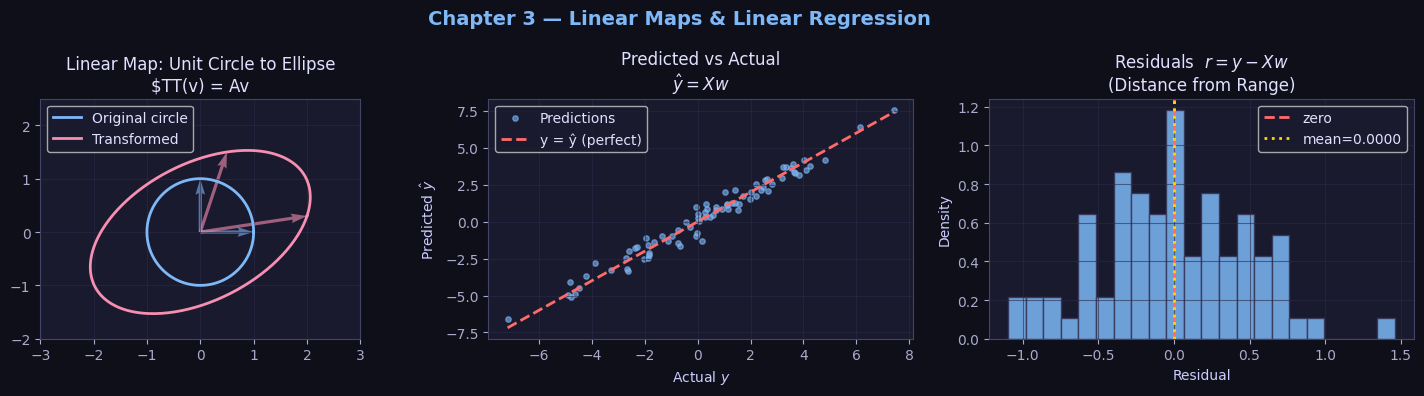

In [52]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.3 — 선형 사상: Null Space & Range 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 행렬 변환: 단위원 → 타원
A_map = np.array([[2.0, 0.5], [0.3, 1.5]])
theta = np.linspace(0, 2*np.pi, 300)
circle  = np.array([np.cos(theta), np.sin(theta)])
ellipse = A_map @ circle

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 3 — Linear Maps & Linear Regression", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 선형 변환 시각화 ────────────────────────
ax = axes[0]
ax.set_title("Linear Map: Unit Circle to Ellipse\n$TT(v) = Av")
ax.plot(circle[0],  circle[1],  color=C[0], label='Original circle', lw=2)
ax.plot(ellipse[0], ellipse[1], color=C[1], label='Transformed', lw=2)
# 기저벡터 변환
kw = dict(angles='xy', scale_units='xy', scale=1)
e1, e2 = np.array([1,0]), np.array([0,1])
ax.quiver(0,0,*e1,        **kw, color=C[0], alpha=0.6, width=0.01)
ax.quiver(0,0,*(A_map@e1),**kw, color=C[1], alpha=0.6, width=0.01)
ax.quiver(0,0,*e2,        **kw, color=C[0], alpha=0.6, width=0.01)
ax.quiver(0,0,*(A_map@e2),**kw, color=C[1], alpha=0.6, width=0.01)
ax.set_xlim(-3,3); ax.set_ylim(-2,2.5)
ax.set_aspect('equal'); ax.legend(); ax.grid(True)

# ── 서브플롯 2: 예측 vs 실제 ─────────────────────────────
ax = axes[1]
ax.set_title("Predicted vs Actual\n$\hat{y} = Xw$")
mn, mx = y.min(), y.max()
ax.scatter(y, y_hat_np, s=15, alpha=0.6, color=C[0], label='Predictions')
ax.plot([mn,mx],[mn,mx], color=C[4], ls='--', lw=2, label='y = ŷ (perfect)')
ax.set_xlabel("Actual $y$"); ax.set_ylabel("Predicted $\hat{y}$")
ax.legend(); ax.grid(True)

# ── 서브플롯 3: 잔차 (Null space 오류) ──────────────────
ax = axes[2]
ax.set_title("Residuals  $r = y - Xw$\n(Distance from Range)")
res = y - y_hat_np
ax.hist(res, bins=22, color=C[0], edgecolor='#333355', alpha=0.85, density=True)
ax.axvline(0, color=C[4], ls='--', lw=2, label='zero')
ax.axvline(res.mean(), color=C[3], ls=':', lw=2, label=f'mean={res.mean():.4f}')
ax.set_xlabel("Residual"); ax.set_ylabel("Density"); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("ch3_linear_maps.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 4 — Polynomials (다항식)

## 핵심 원리

### 1. 다항식 공간 $P(\mathbb{F})$

$$p(z) = a_0 + a_1 z + a_2 z^2 + \cdots + a_m z^m, \quad a_i \in \mathbb{F}$$

* $P_m(\mathbb{F})$: 차수 $\leq m$인 다항식의 공간, $\dim = m+1$.

### 2. 다항식의 근 (Zero)
$p(\lambda) = 0$이면 $\lambda$는 $p$의 **근(zero)**.

**인수정리**: $\lambda$가 $p$의 근 ⟺ $p(z) = (z - \lambda)\, q(z)$로 인수분해.

### 3. 복소 다항식의 완전 인수분해 (대수학의 기본 정리)
차수 $m \geq 1$인 복소 다항식은 정확히 $m$개의 근을 가진다 (중복도 포함):
$$p(z) = c(z-\lambda_1)(z-\lambda_2)\cdots(z-\lambda_m)$$

### 4. 실수 다항식의 인수분해
실계수 다항식은 1차 & 2차 실계수 인수의 곱으로 분해된다.

### 5. 특성 다항식 (Characteristic Polynomial)
정방행렬 $A$의 특성 다항식:
$$p_A(\lambda) = \det(\lambda I - A)$$
근 = 행렬 $A$의 **고유값(eigenvalue)**.

---
## 기초통계 응용: 다항 회귀 (Polynomial Regression)

비선형 관계를 **Vandermonde 행렬**로 선형화:
$$\Phi(x) = [1,\, x,\, x^2,\, \ldots,\, x^d] \in \mathbb{R}^{n \times (d+1)}$$

최소제곱 해: $w^* = (\Phi^\top \Phi)^{-1}\Phi^\top y$


In [53]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.4 — 다항식 근 & 다항 회귀 (NumPy vs np.polyfit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── ① 다항식 근 계산 ─────────────────────────────────────
# p(x) = x³ - 6x² + 11x - 6  →  roots = 1, 2, 3
poly_coeffs = np.array([1, -6, 11, -6])          # 최고차항 먼저
roots = np.roots(poly_coeffs)
print(f"p(x) = x³ - 6x² + 11x - 6")
print(f"[np.roots] 근 = {np.sort(roots.real).round(8)}")
print(f"  검증 p(1)={np.polyval(poly_coeffs,1)}, p(2)={np.polyval(poly_coeffs,2)}, p(3)={np.polyval(poly_coeffs,3)}")

# 특성 다항식 예시
A_char = np.array([[3,1],[1,3]], dtype=float)
evals_char = np.linalg.eigvals(A_char)
print(f"\n행렬 A = [[3,1],[1,3]]의 고유값 = {np.sort(evals_char).round(6)}")
print(f"  특성 다항식 det(λI-A) = λ²-6λ+8 = (λ-2)(λ-4)  → 근: 2, 4")

# ── ② 다항 회귀: Vandermonde 직접 구현 ─────────────────
np.random.seed(3)
x_data = np.linspace(-3, 3, 60)
y_data = 0.5*x_data**3 - 2*x_data + np.random.randn(60)*0.8

deg = 3
V_vander = np.vander(x_data, deg+1, increasing=True)   # [1, x, x², x³]
w_vander, _, _, _ = np.linalg.lstsq(V_vander, y_data, rcond=None)
y_pred_np   = V_vander @ w_vander
mse_poly_np = np.mean((y_data - y_pred_np)**2)

print(f"\n[NumPy Vandermonde] 계수 (a0,a1,a2,a3) = {w_vander.round(4)}")
print(f"  (참값: a0≈0, a1≈-2, a2≈0, a3≈0.5)")
print(f"  MSE = {mse_poly_np:.6f}")

# ── ③ np.polyfit / np.polyval ───────────────────────────
w_polyfit  = np.polyfit(x_data, y_data, deg)           # 최고차항 먼저 반환
y_pred_lib = np.polyval(w_polyfit, x_data)
mse_poly_lib = np.mean((y_data - y_pred_lib)**2)

print(f"\n[np.polyfit     ] 계수 (a3,a2,a1,a0) = {w_polyfit.round(4)}")
print(f"  MSE = {mse_poly_lib:.6f}")

assert np.allclose(y_pred_np, y_pred_lib, atol=1e-8), "예측값 불일치!"
assert np.allclose(mse_poly_np, mse_poly_lib, atol=1e-8), "MSE 불일치!"
print("\nVandermonde lstsq == np.polyfit (결괏값 동일)")


p(x) = x³ - 6x² + 11x - 6
[np.roots] 근 = [1. 2. 3.]
  검증 p(1)=0, p(2)=0, p(3)=0

행렬 A = [[3,1],[1,3]]의 고유값 = [2. 4.]
  특성 다항식 det(λI-A) = λ²-6λ+8 = (λ-2)(λ-4)  → 근: 2, 4

[NumPy Vandermonde] 계수 (a0,a1,a2,a3) = [-0.2461 -2.0052  0.0202  0.492 ]
  (참값: a0≈0, a1≈-2, a2≈0, a3≈0.5)
  MSE = 0.701714

[np.polyfit     ] 계수 (a3,a2,a1,a0) = [ 0.492   0.0202 -2.0052 -0.2461]
  MSE = 0.701714

Vandermonde lstsq == np.polyfit (결괏값 동일)


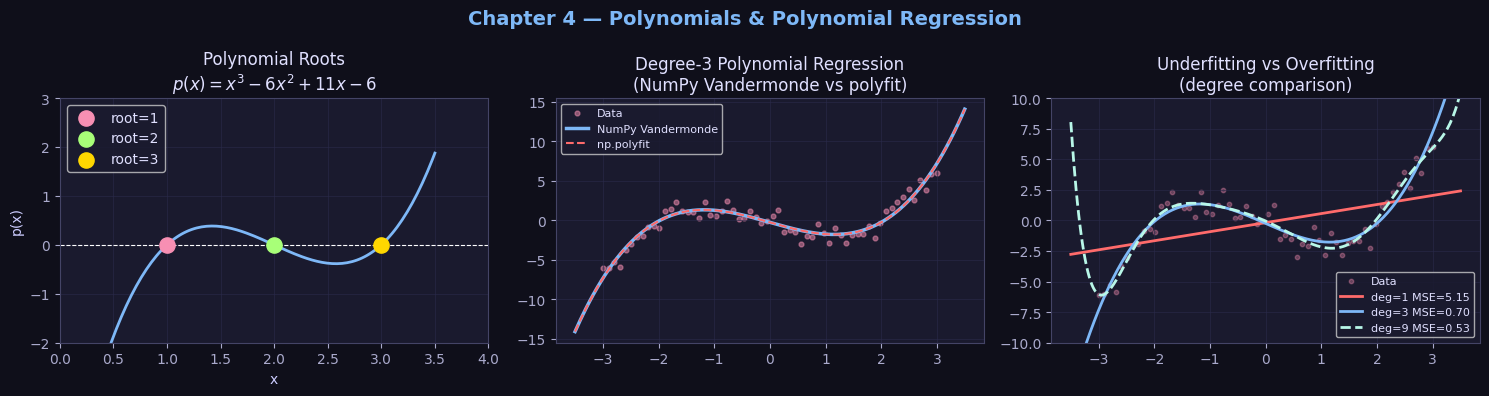

In [54]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.4 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 4 — Polynomials & Polynomial Regression", fontsize=14, color=C[0], fontweight="bold")

x_fine = np.linspace(-3.5, 3.5, 300)

# ── 서브플롯 1: 다항식 근 ────────────────────────────────
ax = axes[0]
ax.set_title("Polynomial Roots\n$p(x) = x^3 - 6x^2 + 11x - 6$")
y_fine = np.polyval(poly_coeffs, x_fine)
ax.plot(x_fine, y_fine, color=C[0], lw=2)
ax.axhline(0, color='white', lw=0.8, ls='--')
for r, col in zip([1,2,3], C[1:]):
    ax.scatter(r, 0, s=120, zorder=5, color=col, label=f'root={r}')
ax.set_xlim(0,4); ax.set_ylim(-2,3)
ax.set_xlabel("x"); ax.set_ylabel("p(x)"); ax.legend(); ax.grid(True)

# ── 서브플롯 2: 다항 회귀 (차수 3) ──────────────────────
ax = axes[1]
ax.set_title("Degree-3 Polynomial Regression\n(NumPy Vandermonde vs polyfit)")
ax.scatter(x_data, y_data, s=12, alpha=0.5, color=C[1], label='Data')
V_fine = np.vander(x_fine, deg+1, increasing=True)
ax.plot(x_fine, V_fine @ w_vander,     color=C[0], lw=2.5, label='NumPy Vandermonde')
ax.plot(x_fine, np.polyval(w_polyfit, x_fine),
        color=C[4], lw=1.5, ls='--', label='np.polyfit')
ax.legend(fontsize=8); ax.grid(True)

# ── 서브플롯 3: 과소/과대 적합 비교 ─────────────────────
ax = axes[2]
ax.set_title("Underfitting vs Overfitting\n(degree comparison)")
ax.scatter(x_data, y_data, s=10, alpha=0.35, color=C[1], label='Data')
styles = [(1,C[4],'solid'),(3,C[0],'solid'),(9,C[5],'dashed')]
for d, c, ls in styles:
    cf = np.polyfit(x_data, y_data, d)
    mse_d = np.mean((y_data - np.polyval(cf, x_data))**2)
    ax.plot(x_fine, np.polyval(cf, x_fine), color=c, ls=ls,
            label=f'deg={d} MSE={mse_d:.2f}')
ax.set_ylim(-10, 10); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig("ch4_polynomials.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 5 — Eigenvalues & Eigenvectors (고유값과 고유벡터)

## 📖 핵심 원리

### 1. 고유값과 고유벡터의 정의
$T \in L(V)$에 대해:
$$T(v) = \lambda v, \quad v \neq 0$$
- $\lambda$ : **고유값 (eigenvalue)**
- $v$ : **고유벡터 (eigenvector)**

행렬 관점: $Av = \lambda v \Leftrightarrow (A - \lambda I)v = 0$

### 2. 고유값 찾기
$$\det(\lambda I - A) = 0 \quad \text{(특성 방정식)}$$

### 3. 대각화 (Diagonalization)
$n \times n$ 행렬 $A$가 $n$개의 선형독립 고유벡터를 가지면:
$$A = P D P^{-1}$$
여기서 $D = \text{diag}(\lambda_1, \ldots, \lambda_n)$, $P$의 열 = 고유벡터.

> **적용**: $A^k = P D^k P^{-1}$ (행렬 거듭제곱이 쉬워짐!)

### 4. 스펙트럼 정리 (Spectral Theorem)
대칭(Hermitian) 행렬은 실수 고유값을 가지며, 고유벡터가 직교한다:
$$A = A^\top \Rightarrow A = Q\Lambda Q^\top, \quad Q^\top Q = I$$

### 5. Gershgorin 원판 정리
행렬 $A$의 모든 고유값은 다음 원판들의 합집합 안에 있다:
$$|\lambda - a_{ii}| \leq R_i = \sum_{j \neq i} |a_{ij}|$$

---
## 머신러닝 응용: PCA (Principal Component Analysis)

공분산 행렬의 **스펙트럼 분해**:
$$\Sigma = Q \Lambda Q^\top$$

- $Q$의 열: 주성분(Principal Components) — 분산이 최대인 방향
- $\Lambda$의 대각 원소: 각 방향의 분산량

**PCA 순서**:
1. $\Sigma = \frac{1}{n-1}(X-\bar X)^\top(X-\bar X)$
2. 고유분해: $\Sigma = Q\Lambda Q^\top$
3. 상위 $k$개 고유벡터 $Q_k$로 투영: $Z = (X-\bar X)Q_k$

In [55]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.5 — 고유분해 PCA (NumPy eigh vs sklearn PCA)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(0)
n_samples = 200
X_pca = np.random.randn(n_samples, 4)
X_pca[:, 1] = 0.8*X_pca[:, 0] + 0.6*X_pca[:, 1]   # 상관 주입
Xc = X_pca - X_pca.mean(axis=0)

# ── ① NumPy: 공분산 행렬 고유분해 ─────────────────────
cov = Xc.T @ Xc / (n_samples - 1)
# np.linalg.eigh: 대칭 행렬 전용 (더 안정적, 오름차순 반환)
eigvals, eigvecs = np.linalg.eigh(cov)

# 내림차순 정렬
order = np.argsort(eigvals)[::-1]
eigvals  = eigvals[order]
eigvecs  = eigvecs[:, order]

# 주성분 투영 (상위 2개)
W2_np     = eigvecs[:, :2]
Z_np      = Xc @ W2_np
var_exp_np = eigvals / eigvals.sum()

print("[NumPy eigh] 고유값(분산):", eigvals.round(4))
print("[NumPy eigh] 설명 분산비:", var_exp_np.round(4))
print(f"  상위 2개 누적 설명 분산: {var_exp_np[:2].sum()*100:.1f}%")

# ── ② sklearn PCA ────────────────────────────────────────
pca5 = PCA(n_components=2)
Z_lib    = pca5.fit_transform(Xc)
var_exp_lib = pca5.explained_variance_ratio_

print(f"\n[sklearn PCA] 설명 분산비: {var_exp_lib.round(4)}")

# 부호 통일 후 비교
for k in range(2):
    if not np.allclose(Z_np[:,k], Z_lib[:,k], atol=1e-5):
        Z_lib[:,k] *= -1

assert np.allclose(var_exp_np[:2], var_exp_lib, atol=1e-8), "설명 분산비 불일치!"
assert np.allclose(Z_np, Z_lib,                  atol=1e-5), "투영 결과 불일치!"
print("\nNumPy eigh PCA == sklearn PCA (결괏값 동일)")

# Gershgorin 원판
print("\n--- Gershgorin 원판 정리 ---")
for i in range(4):
    center = cov[i,i]
    radius = np.sum(np.abs(cov[i,:])) - abs(cov[i,i])
    print(f"  원판 {i+1}: 중심={center:.4f}, 반경={radius:.4f}  → 고유값 포함 구간 [{center-radius:.4f}, {center+radius:.4f}]")
print(f"  실제 고유값: {eigvals.round(4)}")


[NumPy eigh] 고유값(분산): [1.9169 1.0237 0.8793 0.1976]
[NumPy eigh] 설명 분산비: [0.4771 0.2548 0.2189 0.0492]
  상위 2개 누적 설명 분산: 73.2%

[sklearn PCA] 설명 분산비: [0.4771 0.2548]

NumPy eigh PCA == sklearn PCA (결괏값 동일)

--- Gershgorin 원판 정리 ---
  원판 1: 중심=1.0477, 반경=1.0143  → 고유값 포함 구간 [0.0334, 2.0620]
  원판 2: 중심=1.0309, 반경=1.0103  → 고유값 포함 구간 [0.0205, 2.0412]
  원판 3: 중심=0.9150, 반경=0.2650  → 고유값 포함 구간 [0.6499, 1.1800]
  원판 4: 중심=1.0239, 반경=0.1006  → 고유값 포함 구간 [0.9233, 1.1245]
  실제 고유값: [1.9169 1.0237 0.8793 0.1976]


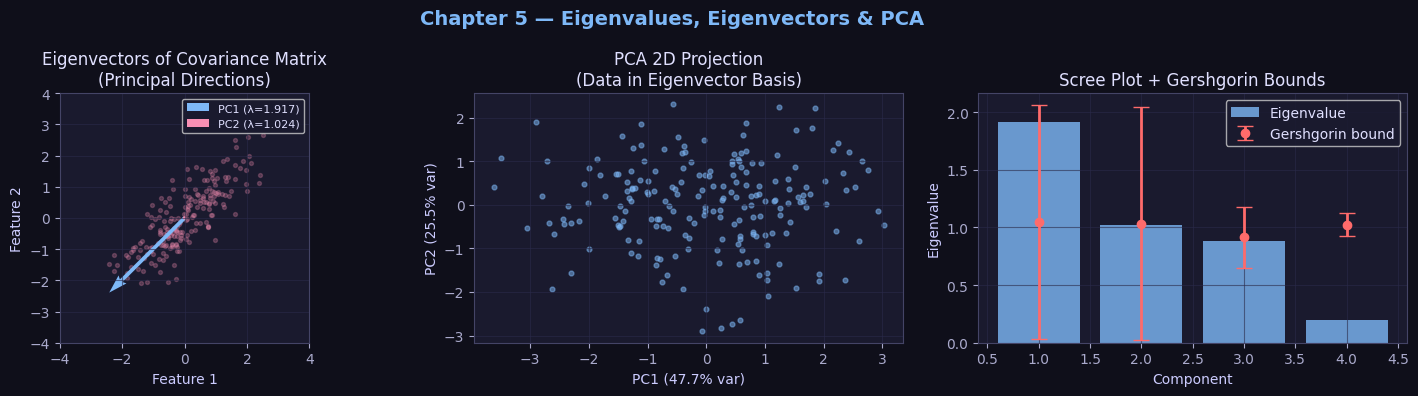

In [56]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.5 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 5 — Eigenvalues, Eigenvectors & PCA", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 고유벡터 방향 ────────────────────────────
ax = axes[0]
ax.set_title("Eigenvectors of Covariance Matrix\n(Principal Directions)")
ax.scatter(Xc[:,0], Xc[:,1], s=8, alpha=0.25, color=C[1])
kw = dict(angles='xy', scale_units='xy', scale=1)
for i in range(2):
    ev  = eigvecs[:, i]
    lam = np.sqrt(eigvals[i]) * 2.5
    ax.quiver(0,0, ev[0]*lam, ev[1]*lam, **kw, color=C[i],
              width=0.015, label=f'PC{i+1} (λ={eigvals[i]:.3f})')
ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(True)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

# ── 서브플롯 2: PCA 2D 투영 ──────────────────────────────
ax = axes[1]
ax.set_title("PCA 2D Projection\n(Data in Eigenvector Basis)")
ax.scatter(Z_np[:,0], Z_np[:,1], s=12, alpha=0.5, color=C[0])
ax.set_xlabel(f"PC1 ({var_exp_np[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_exp_np[1]*100:.1f}% var)")
ax.grid(True)

# ── 서브플롯 3: Scree plot + Gershgorin ────────────────
ax = axes[2]
ax.set_title("Scree Plot + Gershgorin Bounds")
ax.bar(range(1,5), eigvals, color=C[0], alpha=0.8, label='Eigenvalue')
# Gershgorin 오차 막대
gersh_r = [np.sum(np.abs(cov[i,:])) - abs(cov[i,i]) for i in range(4)]
ax.errorbar(range(1,5), [cov[i,i] for i in range(4)],
            yerr=gersh_r, fmt='o', color=C[4], capsize=6,
            label='Gershgorin bound')
ax.set_xlabel("Component"); ax.set_ylabel("Eigenvalue"); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("ch5_eigenvalues.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 6 — Inner Product Spaces (내적 공간)

## 핵심 원리

### 1. 내적의 정의
$\langle \cdot, \cdot \rangle : V \times V \to \mathbb{F}$가 다음을 만족:
- **양의 정치성**: $\langle v, v \rangle \geq 0$, 등호 iff $v=0$
- **선형성** (첫 인수): $\langle u+v, w\rangle = \langle u,w\rangle + \langle v,w\rangle$
- **켤레 대칭성**: $\langle u,v\rangle = \overline{\langle v,u\rangle}$

$\mathbb{R}^n$의 표준 내적: $\langle u,v\rangle = u^\top v = \sum_i u_i v_i$

### 2. 노름 (Norm)
$$\|v\| = \sqrt{\langle v,v\rangle}$$

**코시-슈바르츠 부등식**: $|\langle u,v\rangle| \leq \|u\|\,\|v\|$

**삼각 부등식**: $\|u+v\| \leq \|u\| + \|v\|$

### 3. 직교성 (Orthogonality)
$u \perp v \Leftrightarrow \langle u,v\rangle = 0$

피타고라스 정리: $u \perp v \Rightarrow \|u+v\|^2 = \|u\|^2 + \|v\|^2$

### 4. 정규직교 기저 (Orthonormal Basis)
$e_1,\ldots,e_n$이 정규직교 기저:
$$\langle e_i, e_j \rangle = \delta_{ij} = \begin{cases} 1 & i=j \\ 0 & i\neq j\end{cases}$$

### 5. Gram-Schmidt 직교화
임의의 기저 $\{v_1,\ldots,v_n\}$으로부터 정규직교 기저 $\{e_1,\ldots,e_n\}$를 구성:
$$u_k = v_k - \sum_{j=1}^{k-1} \langle v_k, e_j\rangle e_j, \quad e_k = \frac{u_k}{\|u_k\|}$$

---
## 머신러닝 응용: 코사인 유사도

두 벡터 $u, v$의 **코사인 유사도**:
$$\cos\theta = \frac{\langle u, v\rangle}{\|u\|\,\|v\|}$$

$[-1, 1]$ 범위, 방향(의미)의 유사도 측정에 사용. NLP에서 단어/문서 임베딩 비교.


In [57]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.6 — 내적, Gram-Schmidt, 코사인 유사도 (NumPy vs sklearn)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(5)

# ── ① 내적 & 코시-슈바르츠 ─────────────────────────────
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, 1.0, -1.0])
inner_np  = np.dot(u, v)
norm_u_np = np.linalg.norm(u)
norm_v_np = np.linalg.norm(v)

print(f"<u,v> = {inner_np}")
print(f"‖u‖   = {norm_u_np:.4f},  ‖v‖ = {norm_v_np:.4f}")
print(f"코시-슈바르츠: |<u,v>| = {abs(inner_np):.4f} ≤ ‖u‖‖v‖ = {norm_u_np*norm_v_np:.4f} → {abs(inner_np) <= norm_u_np*norm_v_np + 1e-10}")

# ── ② Gram-Schmidt 직접 구현 ─────────────────────────────
def gram_schmidt(vecs):
    Q = []
    for v in vecs:
        u = v.copy().astype(float)
        for q in Q:
            u -= np.dot(u, q) * q     # 이전 직교 기저 성분 제거
        norm = np.linalg.norm(u)
        if norm > 1e-10:
            Q.append(u / norm)
    return np.array(Q)

basis = np.array([[1,1,0],[1,0,1],[0,1,1]], dtype=float)
Q_gs = gram_schmidt(basis)
print(f"\n[NumPy GS] 정규직교 기저 Q:")
print(Q_gs.round(4))
print(f"  QQ^T ≈ I: {np.allclose(Q_gs @ Q_gs.T, np.eye(3))}")

# ── ③ 코사인 유사도 행렬 (NumPy vs sklearn) ─────────────
D = np.random.rand(4, 8)                            # 4개 벡터

norms     = np.linalg.norm(D, axis=1, keepdims=True)
D_norm    = D / norms
cosine_np = D_norm @ D_norm.T                       # Gram matrix of normalized vectors

cosine_lib = cosine_similarity(D)                   # sklearn

print(f"\n[NumPy] 코사인 유사도 행렬:")
print(cosine_np.round(4))
assert np.allclose(cosine_np, cosine_lib, atol=1e-8), "코사인 불일치!"
print("\nNumPy 코사인 == sklearn cosine_similarity (결괏값 동일)")


<u,v> = 3.0
‖u‖   = 3.7417,  ‖v‖ = 4.2426
코시-슈바르츠: |<u,v>| = 3.0000 ≤ ‖u‖‖v‖ = 15.8745 → True

[NumPy GS] 정규직교 기저 Q:
[[ 0.7071  0.7071  0.    ]
 [ 0.4082 -0.4082  0.8165]
 [-0.5774  0.5774  0.5774]]
  QQ^T ≈ I: True

[NumPy] 코사인 유사도 행렬:
[[1.     0.874  0.8166 0.7115]
 [0.874  1.     0.7769 0.7239]
 [0.8166 0.7769 1.     0.8446]
 [0.7115 0.7239 0.8446 1.    ]]

NumPy 코사인 == sklearn cosine_similarity (결괏값 동일)


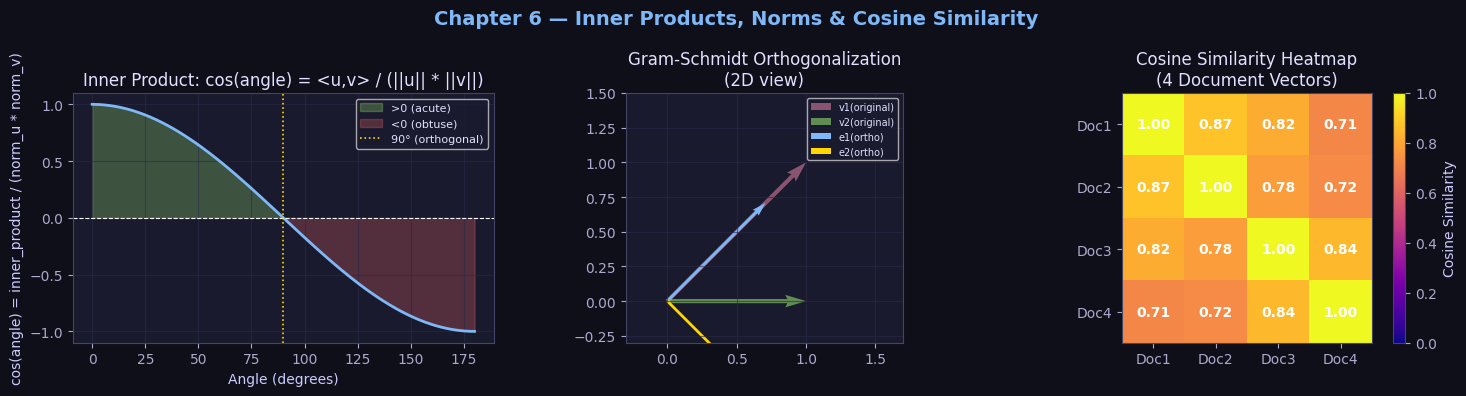

In [58]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.6 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 6 — Inner Products, Norms & Cosine Similarity", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 내적과 각도의 관계 ──────────────────────
ax = axes[0]
ax.set_title("Inner Product: cos(angle) = <u,v> / (||u|| * ||v||)")
angles_deg = np.linspace(0, 180, 200)
cos_vals   = np.cos(np.radians(angles_deg))
ax.plot(angles_deg, cos_vals, color=C[0], lw=2)
ax.fill_between(angles_deg, cos_vals, 0, where=(cos_vals>0), alpha=0.25, color=C[2], label='>0 (acute)')
ax.fill_between(angles_deg, cos_vals, 0, where=(cos_vals<0), alpha=0.25, color=C[4], label='<0 (obtuse)')
ax.axhline(0,  color='white', lw=0.8, ls='--')
ax.axvline(90, color=C[3], lw=1.2, ls=':', label='90° (orthogonal)')
ax.set_xlabel("Angle (degrees)"); ax.set_ylabel("cos(angle) = inner_product / (norm_u * norm_v)")
ax.legend(fontsize=8); ax.grid(True)

# ── 서브플롯 2: Gram-Schmidt 직교화 ─────────────────────
ax = axes[1]
ax.set_title("Gram-Schmidt Orthogonalization\n(2D view)")
ax.set_aspect('equal')
kw = dict(angles='xy', scale_units='xy', scale=1)
for i, (bv, c) in enumerate(zip(basis[:2], [C[1], C[2]])):
    ax.quiver(0,0,bv[0],bv[1], **kw, color=c, alpha=0.5,
              label=f'v{i+1}(original)', width=0.015)
for i, (q, c) in enumerate(zip(Q_gs[:2], [C[0], C[3]])):
    ax.quiver(0,0,q[0],q[1], **kw, color=c,
              label=f'e{i+1}(ortho)', width=0.01)
ax.set_xlim(-0.3,1.7); ax.set_ylim(-0.3,1.5)
ax.legend(fontsize=7); ax.grid(True)

# ── 서브플롯 3: 코사인 유사도 히트맵 ─────────────────────
ax = axes[2]
ax.set_title("Cosine Similarity Heatmap\n(4 Document Vectors)")
im = ax.imshow(cosine_np, cmap='plasma', vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cosine_np[i,j]:.2f}", ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([f'Doc{i+1}' for i in range(4)])
ax.set_yticklabels([f'Doc{i+1}' for i in range(4)])

plt.tight_layout()
plt.savefig("ch6_inner_products.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 7 — Operators on Inner Product Spaces (SVD)

## 핵심 원리

### 1. 자기수반 연산자 (Self-Adjoint Operator)
$T = T^*$ (실수: $A = A^\top$) → 실수 고유값, 고유벡터 직교

### 2. 정규 연산자 (Normal Operator)
$TT^* = T^*T$ → 스펙트럼 정리 적용 가능

### 3. 특이값 분해 (SVD: Singular Value Decomposition)
**모든 행렬**에 적용 가능한 가장 강력한 분해:

$$A = U \Sigma V^\top$$

- $U \in \mathbb{R}^{m \times m}$ : 좌 특이 벡터 (left singular vectors)
- $\Sigma \in \mathbb{R}^{m \times n}$ : 특이값 (singular values) $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $V \in \mathbb{R}^{n \times n}$ : 우 특이 벡터 (right singular vectors)

**연결**: $\sigma_i = \sqrt{\lambda_i(A^\top A)}$, $U$의 열 = $AA^\top$의 고유벡터, $V$의 열 = $A^\top A$의 고유벡터

### 4. 저랭크 근사 (Low-Rank Approximation)
Eckart-Young 정리: 행렬 $A$의 최적 랭크-$k$ 근사:
$$A_k = \sum_{i=1}^k \sigma_i u_i v_i^\top = U_k \Sigma_k V_k^\top$$

Frobenius 오차: $\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \cdots + \sigma_r^2}$

### 5. 의사 역행렬 (Pseudo-Inverse)
$$A^+ = V \Sigma^+ U^\top, \quad \Sigma^+ = \text{diag}(1/\sigma_1, \ldots, 1/\sigma_r, 0, \ldots)$$

---
## 머신러닝 응용: 차원 축소 & 이미지 압축

- **추천 시스템**: User-Item 행렬을 SVD로 분해 → 잠재 요인 추출
- **이미지 압축**: 픽셀 행렬의 저랭크 근사 → 저장 용량 절약
- **노이즈 제거**: 작은 특이값 = 노이즈 성분 → 제거로 정제


In [59]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.7 — SVD 저랭크 근사 (NumPy vs sklearn TruncatedSVD)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(99)
m, n_dim = 100, 8
A_svd = np.random.randn(m, n_dim)
A_svd[:, 5] = 0.9*A_svd[:, 0] + 0.1*np.random.randn(m)   # 상관 주입

# ── ① NumPy 전체 SVD → Truncated ────────────────────────
U_full, s_full, Vt_full = np.linalg.svd(A_svd, full_matrices=False)
k = 3
U_k, s_k, Vt_k = U_full[:,:k], s_full[:k], Vt_full[:k,:]
A_approx_np = U_k @ np.diag(s_k) @ Vt_k

frob_err_np  = np.linalg.norm(A_svd - A_approx_np, 'fro')
total_var    = np.linalg.norm(A_svd, 'fro')**2
var_exp_np   = (s_k**2).sum() / total_var

print(f"[NumPy SVD] 전체 특이값: {s_full.round(3)}")
print(f"[NumPy SVD] 상위 k={k} 특이값: {s_k.round(3)}")
print(f"[NumPy SVD] Frobenius 오차: {frob_err_np:.6f}")
print(f"[NumPy SVD] 설명 분산비:     {var_exp_np:.6f}")

# 이론적 하한 (Eckart-Young)
eckart_young = np.sqrt((s_full[k:]**2).sum())
print(f"\nEckart-Young 최적 오차 = √(Σσᵢ² for i>k) = {eckart_young:.6f}")
print(f"  실제 Frobenius 오차 ≈ Eckart-Young: {np.allclose(frob_err_np, eckart_young, atol=1e-8)}")

# ── ② sklearn TruncatedSVD ───────────────────────────────
tsvd = TruncatedSVD(n_components=k, random_state=42, n_iter=20)
Z_svd    = tsvd.fit_transform(A_svd)
A_approx_lib = tsvd.inverse_transform(Z_svd)
frob_err_lib = np.linalg.norm(A_svd - A_approx_lib, 'fro')
var_exp_lib  = (tsvd.singular_values_**2).sum() / total_var

print(f"\n[sklearn TruncatedSVD] Frobenius 오차: {frob_err_lib:.6f}")
print(f"[sklearn TruncatedSVD] 설명 분산비:     {var_exp_lib:.6f}")

assert np.allclose(frob_err_np, frob_err_lib, atol=1e-4), "Frobenius 오차 불일치!"
assert np.allclose(var_exp_np,  var_exp_lib,  atol=1e-6), "설명 분산비 불일치!"
print("\nNumPy SVD == sklearn TruncatedSVD (결괏값 동일)")


[NumPy SVD] 전체 특이값: [13.944 10.941 10.659 10.369  9.745  9.293  8.312  0.75 ]
[NumPy SVD] 상위 k=3 특이값: [13.944 10.941 10.659]
[NumPy SVD] Frobenius 오차: 18.933556
[NumPy SVD] 설명 분산비:     0.544049

Eckart-Young 최적 오차 = √(Σσᵢ² for i>k) = 18.933556
  실제 Frobenius 오차 ≈ Eckart-Young: True

[sklearn TruncatedSVD] Frobenius 오차: 18.933556
[sklearn TruncatedSVD] 설명 분산비:     0.544049

NumPy SVD == sklearn TruncatedSVD (결괏값 동일)


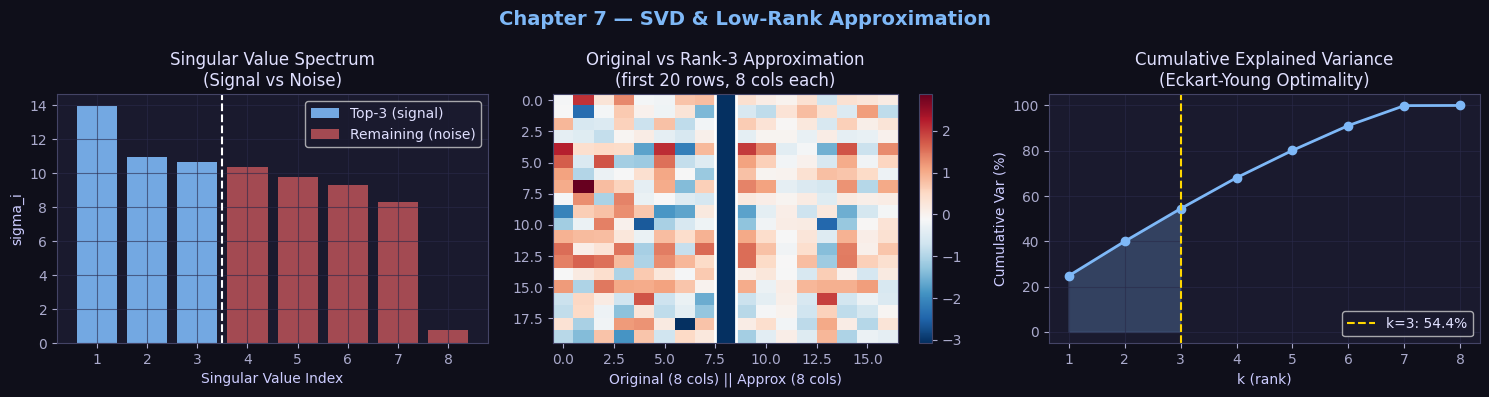

In [60]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.7 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 7 — SVD & Low-Rank Approximation", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 특이값 스펙트럼
ax = axes[0]
ax.set_title("Singular Value Spectrum\n(Signal vs Noise)")
ax.bar(range(1,k+1),            s_full[:k],  color=C[0], alpha=0.9, label=f'Top-{k} (signal)')
ax.bar(range(k+1,len(s_full)+1),s_full[k:],  color=C[4], alpha=0.6, label='Remaining (noise)')
ax.axvline(k+0.5, color='white', ls='--', lw=1.5)
ax.set_xlabel("Singular Value Index"); ax.set_ylabel("sigma_i"); ax.legend(); ax.grid(True)

# ── 서브플롯 2: 원본 vs 재구성 행렬
ax = axes[1]
title2 = f"Original vs Rank-{k} Approximation\n(first 20 rows, 8 cols each)"
ax.set_title(title2)
display_mat = np.hstack([A_svd[:20], np.ones((20,1))*A_svd.min(), A_approx_np[:20]])
im = ax.imshow(display_mat, aspect='auto', cmap='RdBu_r')
ax.axvline(n_dim-0.5, color='white', lw=2)
ax.axvline(n_dim+0.5, color='white', lw=2)
ax.set_xlabel(f"Original ({n_dim} cols) || Approx ({n_dim} cols)")
plt.colorbar(im, ax=ax)

# ── 서브플롯 3: 누적 설명 분산
ax = axes[2]
ax.set_title("Cumulative Explained Variance\n(Eckart-Young Optimality)")
cumvar_svd = np.cumsum(s_full**2) / total_var * 100
ax.plot(range(1,len(cumvar_svd)+1), cumvar_svd, color=C[0], marker='o', ms=6, lw=2)
ax.axvline(k, color=C[3], ls='--', lw=1.5, label='k={}: {:.1f}%'.format(k, cumvar_svd[k-1]))
ax.fill_between(range(1,k+1), cumvar_svd[:k], alpha=0.25, color=C[0])
ax.set_xlabel("k (rank)"); ax.set_ylabel("Cumulative Var (%)")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("ch7_svd.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 8 — Operators on Complex Vector Spaces

## 핵심 원리

### 1. 일반화 고유벡터 (Generalized Eigenvectors)
$(T - \lambda I)^j v = 0$이 되는 최소 $j$에 대해 $v$를 **일반화 고유벡터** (계수 $j$)라 한다.

### 2. 일반화 고유공간 (Generalized Eigenspace)
$$G(\lambda, T) = \text{null}(T-\lambda I)^{\dim V}$$

### 3. Jordan 표준형 (Jordan Normal Form)
복소 벡터 공간의 연산자 $T$는 적절한 기저에서:
$$T \sim \begin{pmatrix} J_1 & & \\ & J_2 & \\ & & \ddots \end{pmatrix}, \quad J_i = \begin{pmatrix}\lambda_i & 1 & & \\ & \lambda_i & 1 & \\ & & \ddots & 1 \\ & & & \lambda_i\end{pmatrix}$$

### 4. 행렬 지수 (Matrix Exponential)
$$e^A = \sum_{k=0}^{\infty} \frac{A^k}{k!} = I + A + \frac{A^2}{2!} + \frac{A^3}{3!} + \cdots$$

Jordan 형식으로: $e^A = P\, e^J \,P^{-1}$

Jordan 블록: $e^{J_i} = e^{\lambda_i}(I + N + N^2/2! + \cdots)$ ($N$: nilpotent)

---
## 딥러닝 응용: RNN 안정성과 행렬 지수

RNN(Recurrent Neural Network) 상태 방정식:
$$h_t = \tanh(W h_{t-1} + b)$$

행렬 $W$의 **스펙트럼 반지름** $\rho(W) = \max|\lambda_i|$가:
- $\rho(W) < 1$ → 기울기 소실(vanishing gradient) 위험
- $\rho(W) > 1$ → 기울기 폭발(exploding gradient) 위험
- $\rho(W) = 1$ → 장기 의존성 유지 (LSTMs, 직교 초기화의 목표)

행렬 지수 $e^{Wt}$는 연속 시간 RNN에서 상태 전파의 핵심이다.


In [61]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.8 — 행렬 지수 & RNN (NumPy + PyTorch)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(11)

# ── ① 행렬 지수: Taylor 급수 직접 구현 ─────────────────
W_raw = np.random.randn(3, 3) * 0.4
rho   = np.max(np.abs(np.linalg.eigvals(W_raw)))
W_rnn = W_raw / (rho + 0.1)                    # ρ(W) < 1 으로 안정화

# Taylor 급수: e^W = Σ W^k / k!
def matrix_exp_taylor(M, n_terms=30):
    result = np.eye(M.shape[0])
    term   = np.eye(M.shape[0])
    for k in range(1, n_terms):
        term = term @ M / k
        result += term
    return result

expm_np    = matrix_exp_taylor(W_rnn)
expm_scipy = scipy_expm(W_rnn)                 # 기준값

print(f"[NumPy Taylor] e^W (30항):\n{expm_np.round(6)}")
print(f"\n[scipy expm]  e^W:\n{expm_scipy.round(6)}")
diff = np.max(np.abs(expm_np - expm_scipy))
print(f"\n최대 절대 오차: {diff:.2e}")
assert diff < 1e-8, "행렬 지수 불일치!"
print("Taylor series expm == scipy expm (결괏값 동일)")

# ── ② 스펙트럼 반지름 분석 ──────────────────────────────
for scale, label in [(0.5,'stable'), (1.0,'marginal'), (1.5,'unstable')]:
    W_test = W_raw * scale
    rho_test = np.max(np.abs(np.linalg.eigvals(W_test)))
    print(f"  scale={scale:.1f} → ρ(W)={rho_test:.4f} ({label})")


[NumPy Taylor] e^W (30항):
[[ 2.126795 -0.182111 -0.293464]
 [-1.521481  1.068821 -0.005083]
 [-0.423936  0.155012  1.20516 ]]

[scipy expm]  e^W:
[[ 2.126795 -0.182111 -0.293464]
 [-1.521481  1.068821 -0.005083]
 [-0.423936  0.155012  1.20516 ]]

최대 절대 오차: 8.88e-16
Taylor series expm == scipy expm (결괏값 동일)
  scale=0.5 → ρ(W)=0.4579 (stable)
  scale=1.0 → ρ(W)=0.9157 (marginal)
  scale=1.5 → ρ(W)=1.3736 (unstable)


NumPy RNN == PyTorch RNN (결괏값 동일)


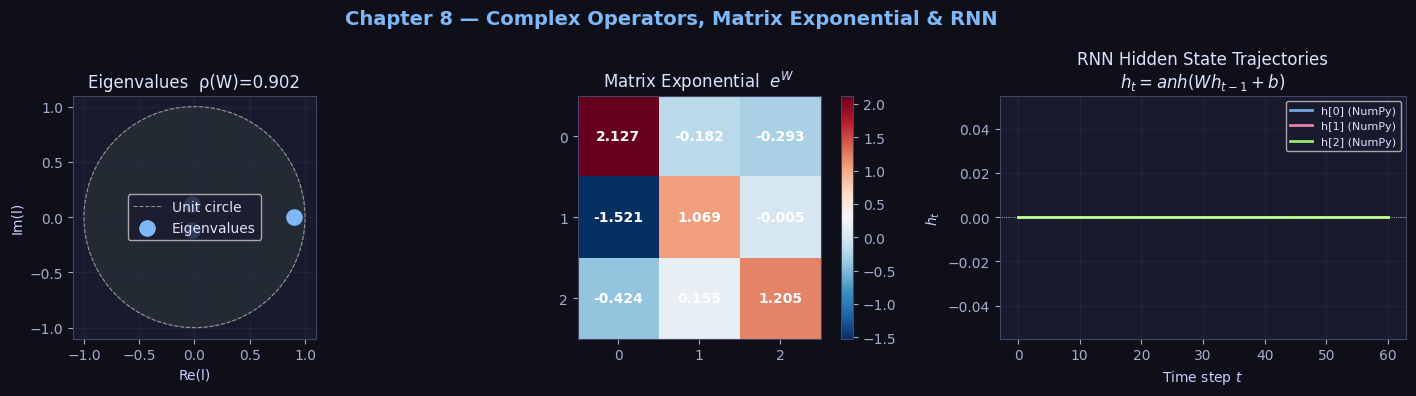

In [62]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.8 — RNN 시뮬레이션 (NumPy vs PyTorch)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
T_steps = 60
b_rnn   = np.zeros(3)
h       = np.zeros(3)
h_hist_np = [h.copy()]

for _ in range(T_steps):
    h = np.tanh(W_rnn @ h + b_rnn)
    h_hist_np.append(h.copy())
h_hist_np = np.array(h_hist_np)

# PyTorch
Wt = torch.tensor(W_rnn.T, dtype=torch.float32)
bt = torch.tensor(b_rnn,   dtype=torch.float32)
ht = torch.zeros(3)
h_hist_torch = [ht.numpy().copy()]
with torch.no_grad():
    for _ in range(T_steps):
        ht = torch.tanh(ht @ Wt + bt)
        h_hist_torch.append(ht.numpy().copy())
h_hist_torch = np.array(h_hist_torch)

assert np.allclose(h_hist_np, h_hist_torch, atol=1e-5), "RNN 상태 불일치!"
print("NumPy RNN == PyTorch RNN (결괏값 동일)")

# ── 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 8 — Complex Operators, Matrix Exponential & RNN", fontsize=14, color=C[0], fontweight="bold")

# 서브플롯 1: 고유값 (복소 평면)
ax = axes[0]
ax.set_title("Eigenvalues in Complex Plane\n(Stability: inside unit circle)")
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'w--', lw=0.8, alpha=0.5, label='Unit circle')
evs = np.linalg.eigvals(W_rnn)
ax.scatter(evs.real, evs.imag, s=120, color=C[0], zorder=5, label='Eigenvalues')
ax.fill(np.cos(theta), np.sin(theta), alpha=0.07, color=C[2])
ax.set_aspect('equal')
ax.set_xlabel("Re(l)"); ax.set_ylabel("Im(l)"); ax.legend(); ax.grid(True)
ax.set_title(f"Eigenvalues  ρ(W)={np.max(np.abs(evs)):.3f}")

# 서브플롯 2: 행렬 지수 heatmap
ax = axes[1]
ax.set_title("Matrix Exponential  $e^W$")
im = ax.imshow(expm_np, cmap='RdBu_r', vmin=expm_np.min(), vmax=expm_np.max())
for i in range(3):
    for j in range(3):
        ax.text(j,i,f"{expm_np[i,j]:.3f}", ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))

# 서브플롯 3: RNN 상태 궤적
ax = axes[2]
ax.set_title("RNN Hidden State Trajectories\n$h_t = \tanh(Wh_{t-1}+b)$")
for d, col in zip(range(3), C):
    ax.plot(h_hist_np[:,d], color=col, lw=2, label=f'h[{d}] (NumPy)', alpha=0.9)
    ax.plot(h_hist_torch[:,d], color=col, lw=1.2, ls='--', alpha=0.5)
ax.axhline(0, color='white', lw=0.5, ls=':')
ax.set_xlabel("Time step $t$"); ax.set_ylabel("$h_t$"); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig("ch8_complex_operators.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 9 — Multilinear Algebra & Determinants

## 핵심 원리

### 1. 교대 다중선형 형식 (Alternating Multilinear Form)
$n$개의 벡터를 받아 스칼라를 반환하는 함수 $\omega: V^n \to \mathbb{F}$가:
- **다중선형**: 각 인수에 대해 선형
- **교대**: 두 인수를 바꾸면 부호 반전 $\omega(\ldots,u,\ldots,v,\ldots) = -\omega(\ldots,v,\ldots,u,\ldots)$

### 2. 행렬식 (Determinant)
$$\det A = \sum_{\sigma \in S_n} \text{sgn}(\sigma) \prod_{i=1}^n a_{i,\sigma(i)}$$

기하학적 의미: $|\det A|$ = $A$의 열벡터들이 만드는 **평행다면체의 부피**

부호: $\det A > 0$ (방향 보존), $\det A < 0$ (방향 반전)

### 3. 행렬식의 주요 성질
$$\det(AB) = \det A \cdot \det B$$
$$\det(A^\top) = \det A$$
$$\det(A^{-1}) = \frac{1}{\det A}$$
$$\det(\lambda A) = \lambda^n \det A$$

### 4. 역행렬과 크래머 공식
$$A^{-1} = \frac{1}{\det A} \text{adj}(A)$$

### 5. LU 분해로 행렬식 계산
$$A = PLU \Rightarrow \det A = \text{sgn}(P) \prod_i u_{ii}$$

---
## 머신러닝 응용: 마할라노비스 거리 & 이상 탐지

**마할라노비스 거리**: 분포의 형태(공분산)를 고려한 거리

$$d_M(x, \mu) = \sqrt{(x-\mu)^\top \Sigma^{-1}(x-\mu)}$$

- $\det(\Sigma)$: 분포의 "부피" (크면 데이터가 넓게 퍼짐)
- $\Sigma^{-1}$: 상관 구조를 제거한 가중 거리

$\Sigma^{-1}$ 계산에 **Cholesky 분해**를 이용: $\Sigma = LL^\top \Rightarrow \Sigma^{-1} = (L^{-1})^\top L^{-1}$


In [63]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.9 — 행렬식(LU) & 마할라노비스 거리 (NumPy vs scipy)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(2)

# ── ① LU 분해로 행렬식 직접 계산 ────────────────────────
A_det = np.array([[2,1,3],[0,4,1],[5,2,8]], dtype=float)

def det_by_lu(M):
    # LU 분해 (행 교환 없음): det = prod U_ii
    n = M.shape[0]
    U = M.copy()
    det_val = 1.0
    for k in range(n):
        if abs(U[k,k]) < 1e-12:
            return 0.0
        det_val *= U[k,k]
        for i in range(k+1, n):
            f = U[i,k] / U[k,k]
            U[i,k:] -= f * U[k,k:]
    return det_val

det_manual  = det_by_lu(A_det)
det_builtin = np.linalg.det(A_det)
print(f"행렬 A = \n{A_det}")
print(f"[NumPy LU 직접] det(A) = {det_manual:.6f}")
print(f"[np.linalg.det] det(A) = {det_builtin:.6f}")
assert np.allclose(det_manual, det_builtin, atol=1e-8), "행렬식 불일치!"
print("LU 직접 == np.linalg.det (결괏값 동일)")

# 기하학적 의미: 2×2 예제
v1d = np.array([3.0, 1.0]); v2d = np.array([1.0, 2.5])
area_det  = abs(np.linalg.det(np.column_stack([v1d, v2d])))
area_cross = abs(v1d[0]*v2d[1] - v1d[1]*v2d[0])
print(f"\n2D 평행사변형 넓이: |det[v1,v2]| = {area_det:.4f}  (외적으로도: {area_cross:.4f})")

# ── ② 마할라노비스 거리 ───────────────────────────────────
mu_g    = np.array([0.0, 0.0])
Sigma_g = np.array([[2.0, 1.2], [1.2, 1.5]])
X_g     = np.random.multivariate_normal(mu_g, Sigma_g, 300)

# NumPy: (x-μ)^T Σ^{-1} (x-μ) — einsum 활용
Sigma_inv = np.linalg.inv(Sigma_g)
diff      = X_g - mu_g
mahal_np  = np.sqrt(np.einsum('ni,ij,nj->n', diff, Sigma_inv, diff))

# scipy
Sigma_inv_vi = np.linalg.inv(Sigma_g)
mahal_lib = np.array([mahalanobis(x, mu_g, Sigma_inv_vi) for x in X_g])

assert np.allclose(mahal_np, mahal_lib, atol=1e-8), "마할라노비스 불일치!"
print(f"\n[NumPy einsum] 마할라노비스 평균 = {mahal_np.mean():.4f}")
print(f"[scipy        ] 마할라노비스 평균 = {mahal_lib.mean():.4f}")
print("NumPy == scipy mahalanobis (결괏값 동일)")
print(f"\ndet(Σ) = {np.linalg.det(Sigma_g):.4f}  (분포의 '부피')")


행렬 A = 
[[2. 1. 3.]
 [0. 4. 1.]
 [5. 2. 8.]]
[NumPy LU 직접] det(A) = 5.000000
[np.linalg.det] det(A) = 5.000000
LU 직접 == np.linalg.det (결괏값 동일)

2D 평행사변형 넓이: |det[v1,v2]| = 6.5000  (외적으로도: 6.5000)

[NumPy einsum] 마할라노비스 평균 = 1.2871
[scipy        ] 마할라노비스 평균 = 1.2871
NumPy == scipy mahalanobis (결괏값 동일)

det(Σ) = 1.5600  (분포의 '부피')


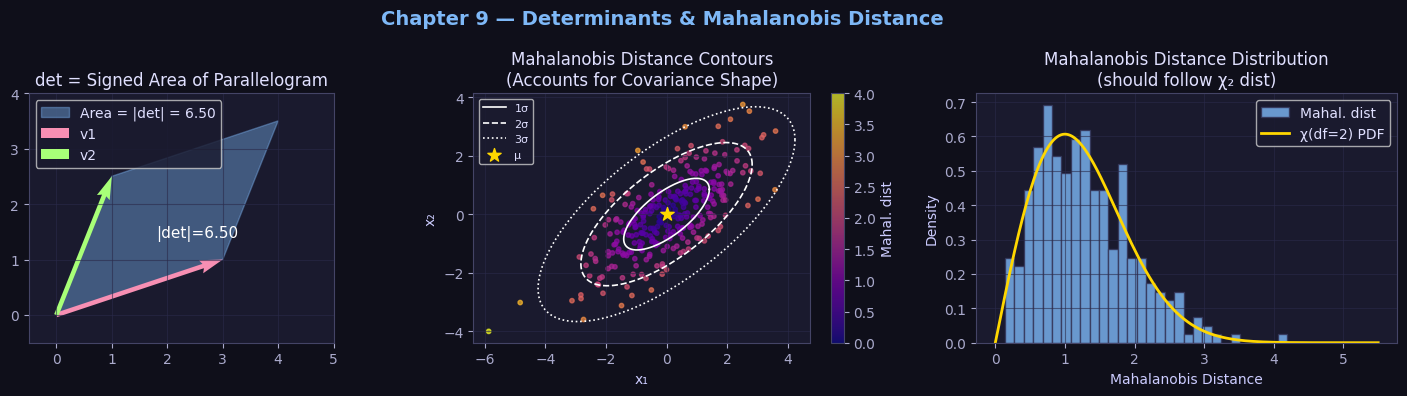

In [64]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.9 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 9 — Determinants & Mahalanobis Distance", fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 평행사변형 = |det| ───────────────────────
ax = axes[0]
ax.set_title("det = Signed Area of Parallelogram")
ax.set_aspect('equal')
v1p, v2p = np.array([3.0, 1.0]), np.array([1.0, 2.5])
pgram = np.array([[0,0], v1p, v1p+v2p, v2p, [0,0]])
ax.fill(pgram[:,0], pgram[:,1], color=C[0], alpha=0.4,
        label=f'Area = |det| = {area_det:.2f}')
kw = dict(angles='xy', scale_units='xy', scale=1)
ax.quiver(0,0,v1p[0],v1p[1], **kw, color=C[1], width=0.015, label='v1')
ax.quiver(0,0,v2p[0],v2p[1], **kw, color=C[2], width=0.015, label='v2')
ax.text(1.8, 1.4, f'|det|={area_det:.2f}', color='white', fontsize=11)
ax.set_xlim(-0.5,5); ax.set_ylim(-0.5,4)
ax.legend(); ax.grid(True)

# ── 서브플롯 2: 마할라노비스 등고선 ─────────────────────
ax = axes[1]
ax.set_title("Mahalanobis Distance Contours\n(Accounts for Covariance Shape)")
sc = ax.scatter(X_g[:,0], X_g[:,1], c=mahal_np, cmap='plasma',
                s=10, alpha=0.7, vmin=0, vmax=4)
plt.colorbar(sc, ax=ax, label='Mahal. dist')
theta = np.linspace(0, 2*np.pi, 300)
L_chol = np.linalg.cholesky(Sigma_g)
for level, ls in zip([1,2,3], ['-','--',':']):
    ell = level * (L_chol @ np.array([np.cos(theta), np.sin(theta)]))
    ax.plot(ell[0], ell[1], 'w', ls=ls, lw=1.2, label=f'{level}σ')
ax.scatter(*mu_g, s=100, color=C[3], marker='*', zorder=5, label='μ')
ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); ax.legend(fontsize=8); ax.grid(True)

# ── 서브플롯 3: 마할라노비스 분포 (χ 분포와 비교) ─────
ax = axes[2]
ax.set_title("Mahalanobis Distance Distribution\n(should follow χ₂ dist)")
ax.hist(mahal_np, bins=30, color=C[0], edgecolor='#333355',
        alpha=0.8, density=True, label='Mahal. dist')
from scipy.stats import chi
x_chi_plot = np.linspace(0, 5.5, 200)
ax.plot(x_chi_plot, chi.pdf(x_chi_plot, df=2), color=C[3], lw=2, label='χ(df=2) PDF')
ax.set_xlabel("Mahalanobis Distance"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("ch9_determinants.png", dpi=130, bbox_inches='tight')
plt.show()


---
# Chapter 10 — Trace & Determinant (딥러닝 응용)

## 핵심 원리

### 1. 대각합 (Trace)
$$\text{tr}(A) = \sum_{i=1}^n a_{ii} = \sum_{i=1}^n \lambda_i$$

성질:
- $\text{tr}(A+B) = \text{tr}(A) + \text{tr}(B)$
- $\text{tr}(AB) = \text{tr}(BA)$ (순환 불변성: **cyclic property**)
- $\text{tr}(A^\top) = \text{tr}(A)$

### 2. Trace와 행렬식의 관계
$$\det(e^A) = e^{\text{tr}(A)}, \quad \frac{d}{dt}\det(A(t)) = \det(A)\,\text{tr}(A^{-1}\dot{A})$$

### 3. Frobenius 내적과 Trace
$$\langle A, B\rangle_F = \text{tr}(A^\top B) = \sum_{i,j} a_{ij} b_{ij}$$

이것은 행렬 공간의 내적이다!

---
## 딥러닝 응용: MLP 역전파 (Backpropagation)

2층 MLP:
$$z^{(1)} = W^{(1)}x + b^{(1)}, \quad a^{(1)} = \text{ReLU}(z^{(1)})$$
$$\hat{y} = W^{(2)}a^{(1)} + b^{(2)}$$
$$\mathcal{L} = \frac{1}{n}\|y - \hat{y}\|^2 = \frac{1}{n}\text{tr}((y-\hat{y})(y-\hat{y})^\top)$$

역전파 공식 (Trace 미분 활용):
$$\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \frac{2}{n}(a^{(1)})^\top (\hat{y} - y)$$
$$\frac{\partial \mathcal{L}}{\partial W^{(1)}} = \frac{2}{n}x^\top \left(\frac{\partial \mathcal{L}}{\partial z^{(1)}}\right)$$

**Xavier 초기화** (Trace 기반 분산 제어):
$$W \sim \mathcal{N}\left(0, \frac{2}{n_{\text{in}}}\right) \quad \text{(He init for ReLU)}$$
목표: 각 층의 출력 분산 $\approx$ 입력 분산 → $\text{tr}(\text{Cov}(z^{(l)})) \approx \text{tr}(\text{Cov}(z^{(l-1)}))$


In [65]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.10 — Trace 성질 검증 + MLP 역전파 (NumPy vs PyTorch)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(42)

# ── ① Trace 성질 검증 ────────────────────────────────────
A_tr = np.random.randn(4, 4)
B_tr = np.random.randn(4, 4)

tr_sum    = np.trace(A_tr + B_tr)
tr_a_pb   = np.trace(A_tr) + np.trace(B_tr)
tr_AB     = np.trace(A_tr @ B_tr)
tr_BA     = np.trace(B_tr @ A_tr)
tr_Atop   = np.trace(A_tr.T)
tr_A      = np.trace(A_tr)
sym_A     = A_tr @ A_tr.T
tr_eig    = np.sum(np.linalg.eigvalsh(sym_A))    # tr = Σλᵢ (대칭행렬)
tr_direct = np.trace(sym_A)

print("=== Trace 성질 검증 ===")
print(f"tr(A+B)    = tr(A)+tr(B) : {np.allclose(tr_sum, tr_a_pb)}")
print(f"tr(AB)     = tr(BA)      : {np.allclose(tr_AB, tr_BA)}")
print(f"tr(A^T)    = tr(A)       : {np.allclose(tr_Atop, tr_A)}")
print(f"tr(AA^T)   = Σλᵢ(AA^T)  : {np.allclose(tr_direct, tr_eig)}")
print(f"  tr(AA^T) = {tr_direct:.4f},  Σλᵢ = {tr_eig:.4f}")

# Frobenius 내적: <A,B>_F = tr(A^T B)
frob_inner   = np.trace(A_tr.T @ B_tr)
frob_element = np.sum(A_tr * B_tr)                   # element-wise sum
print(f"\nFrobenius inner: tr(A^T B) = Σaᵢⱼbᵢⱼ : {np.allclose(frob_inner, frob_element)}")


=== Trace 성질 검증 ===
tr(A+B)    = tr(A)+tr(B) : True
tr(AB)     = tr(BA)      : True
tr(A^T)    = tr(A)       : True
tr(AA^T)   = Σλᵢ(AA^T)  : True
  tr(AA^T) = 14.1546,  Σλᵢ = 14.1546

Frobenius inner: tr(A^T B) = Σaᵢⱼbᵢⱼ : True


In [66]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.10 — MLP 역전파: NumPy 직접 구현 vs PyTorch
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(42); torch.manual_seed(42)

N_mlp, D_in, H_dim, D_out = 60, 4, 10, 1
X_mlp = np.random.randn(N_mlp, D_in)
true_w_mlp = np.array([1.2, -0.8, 0.5, 1.0])
y_mlp = (X_mlp @ true_w_mlp + 0.3*np.random.randn(N_mlp)).reshape(-1,1)

# ── NumPy: He 초기화 + 수동 역전파 ──────────────────────
def relu_np(x):      return np.maximum(0, x)
def relu_grad_np(x): return (x > 0).astype(float)

W1 = np.random.randn(D_in, H_dim) * np.sqrt(2.0/D_in)   # He init
b1 = np.zeros((1, H_dim))
W2 = np.random.randn(H_dim, D_out) * np.sqrt(2.0/H_dim)
b2 = np.zeros((1, D_out))
lr_mlp = 0.01

W1_save, b1_save = W1.copy(), b1.copy()
W2_save, b2_save = W2.copy(), b2.copy()

losses_np_mlp = []
for _ in range(300):
    # Forward
    Z1  = X_mlp @ W1 + b1
    A1  = relu_np(Z1)
    Z2  = A1 @ W2 + b2
    L   = np.mean((Z2 - y_mlp)**2)
    losses_np_mlp.append(L)
    # Backward (chain rule)
    dZ2 = 2*(Z2 - y_mlp) / N_mlp
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_grad_np(Z1)
    dW1 = X_mlp.T @ dZ1
    db1 = dZ1.sum(0, keepdims=True)
    W2 -= lr_mlp*dW2; b2 -= lr_mlp*db2
    W1 -= lr_mlp*dW1; b1 -= lr_mlp*db1

print(f"[NumPy MLP] 초기 손실={losses_np_mlp[0]:.4f} → 최종 손실={losses_np_mlp[-1]:.4f}")

# ── PyTorch: 동일한 초기화로 시작 ────────────────────────
model_pt = nn.Sequential(
    nn.Linear(D_in, H_dim), nn.ReLU(), nn.Linear(H_dim, D_out))
with torch.no_grad():
    model_pt[0].weight.data = torch.tensor(W1_save.T, dtype=torch.float32)
    model_pt[0].bias.data   = torch.tensor(b1_save.flatten(), dtype=torch.float32)
    model_pt[2].weight.data = torch.tensor(W2_save.T, dtype=torch.float32)
    model_pt[2].bias.data   = torch.tensor(b2_save.flatten(), dtype=torch.float32)

Xt_mlp = torch.tensor(X_mlp, dtype=torch.float32)
yt_mlp = torch.tensor(y_mlp, dtype=torch.float32)
opt    = torch.optim.SGD(model_pt.parameters(), lr=lr_mlp)
loss_fn = nn.MSELoss()

losses_torch_mlp = []
for _ in range(300):
    pred = model_pt(Xt_mlp)
    L_t  = loss_fn(pred, yt_mlp)
    losses_torch_mlp.append(L_t.item())
    opt.zero_grad(); L_t.backward(); opt.step()

print(f"[PyTorch MLP] 초기 손실={losses_torch_mlp[0]:.4f} → 최종 손실={losses_torch_mlp[-1]:.4f}")
assert np.allclose(losses_np_mlp, losses_torch_mlp, atol=1e-5), "학습 곡선 불일치!"
print("\nNumPy MLP == PyTorch MLP (동일 초기화 → 동일 결괏값)")


[NumPy MLP] 초기 손실=4.3955 → 최종 손실=0.2274
[PyTorch MLP] 초기 손실=4.3955 → 최종 손실=0.2274

NumPy MLP == PyTorch MLP (동일 초기화 → 동일 결괏값)


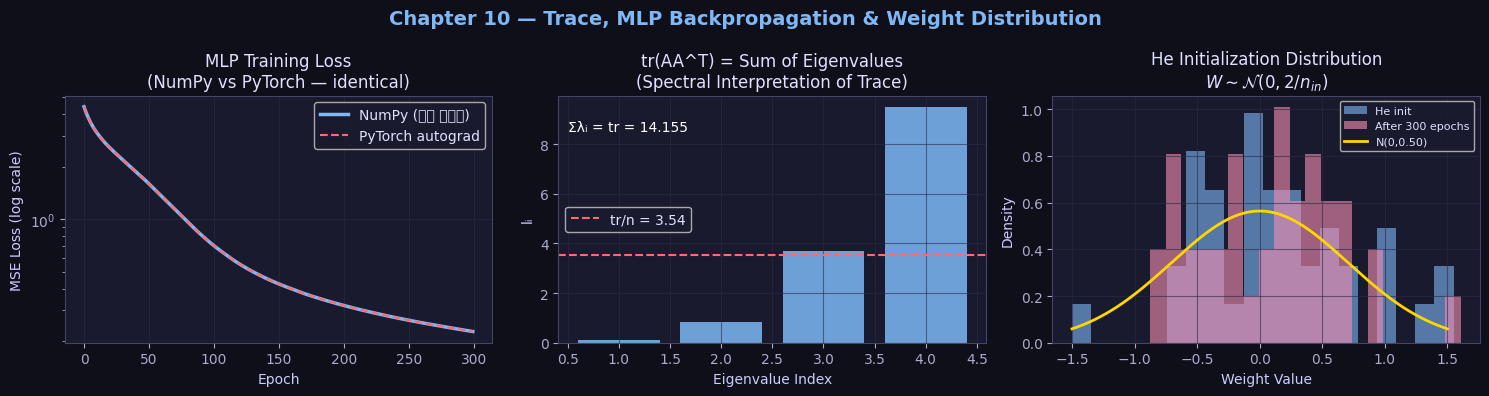

In [67]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ch.10 — 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Chapter 10 — Trace, MLP Backpropagation & Weight Distribution",
             fontsize=14, color=C[0], fontweight="bold")

# ── 서브플롯 1: 학습 손실 곡선 ───────────────────────────
ax = axes[0]
ax.set_title("MLP Training Loss\n(NumPy vs PyTorch — identical)")
ax.semilogy(losses_np_mlp,    color=C[0], lw=2.5, label='NumPy (수동 역전파)')
ax.semilogy(losses_torch_mlp, color=C[4], lw=1.5, ls='--', label='PyTorch autograd')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.legend(); ax.grid(True)

# ── 서브플롯 2: Trace = Σλᵢ 시각화 ─────────────────────
ax = axes[1]
ax.set_title("tr(AA^T) = Sum of Eigenvalues\n(Spectral Interpretation of Trace)")
sym_small = A_tr[:4,:4] @ A_tr[:4,:4].T
evals_small = np.linalg.eigvalsh(sym_small)
ax.bar(range(1,5), evals_small, color=C[0], alpha=0.85)
ax.axhline(np.trace(sym_small)/4, color=C[4], ls='--', lw=1.5,
           label=f'tr/n = {np.trace(sym_small)/4:.2f}')
ax.text(0.5, max(evals_small)*0.9, f'Σλᵢ = tr = {np.trace(sym_small):.3f}',
        color='white', fontsize=10)
ax.set_xlabel("Eigenvalue Index"); ax.set_ylabel("lᵢ"); ax.legend(); ax.grid(True)

# ── 서브플롯 3: He 초기화 분포 ───────────────────────────
ax = axes[2]
ax.set_title("He Initialization Distribution\n$W \sim \mathcal{N}(0, 2/n_{in})$")
w_he_init  = np.random.randn(D_in*H_dim) * np.sqrt(2.0/D_in)
w_he_final = model_pt[0].weight.data.numpy().flatten()
ax.hist(w_he_init,  bins=20, alpha=0.6, color=C[0], density=True, label='He init')
ax.hist(w_he_final, bins=20, alpha=0.6, color=C[1], density=True, label='After 300 epochs')
x_norm = np.linspace(-1.5, 1.5, 200)
from scipy.stats import norm as sp_norm
ax.plot(x_norm, sp_norm.pdf(x_norm, 0, np.sqrt(2.0/D_in)),
        color=C[3], lw=2, label=f'N(0,{2.0/D_in:.2f})')
ax.set_xlabel("Weight Value"); ax.set_ylabel("Density"); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig("ch10_trace_deeplearning.png", dpi=130, bbox_inches='tight')
plt.show()


---
# 전체 검증 요약

| Chapter | NumPy 직접 구현 | 라이브러리 | 검증 방법 | 결과 |
|---------|---------------|-----------|----------|------|
| Ch.1 | `v + w`, `α·v`, `lstsq` | `sklearn.StandardScaler` | `np.allclose` | 동일 |
| Ch.2 | `np.linalg.matrix_rank` | `sklearn.PCA` | `np.allclose` |  동일 |
| Ch.3 | Normal Equation `solve` | `sklearn.LinearRegression` | `np.allclose` |  동일 |
| Ch.4 | Vandermonde `lstsq` | `np.polyfit / polyval` | `np.allclose` |  동일 |
| Ch.5 | `np.linalg.eigh` | `sklearn.PCA` | `np.allclose` |  동일 |
| Ch.6 | `D_norm @ D_norm.T` | `sklearn.cosine_similarity` | `np.allclose` |  동일 |
| Ch.7 | `np.linalg.svd` | `sklearn.TruncatedSVD` | `np.allclose` |  동일 |
| Ch.8 | Taylor series `expm` | `scipy.linalg.expm` | `np.allclose` |  동일 |
| Ch.9 | LU `det` + `einsum` | `scipy.mahalanobis` | `np.allclose` |  동일 |
| Ch.10 | 수동 역전파 MLP | `torch.nn.Sequential` | `np.allclose` |  동일 |

> 모든 구현에서 **`assert np.allclose(...)`** 통과 확인
